## Le Club Francais du Vin

### 1. Import some Python modules

In [ ]:
import numpy as np
import scipy.stats as stats
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline

### 2. Read data from Le Club

In [ ]:
#---Populate the list and dictionary below using the file "wines_historical.csv"
data = open('Historical.csv','r')
lines = data.readlines()
lines = [line.rstrip('\n') for line in lines]
data.close()

ID_historical = []
wines_historical = {}

cnt = 0
for line in lines:
    if cnt == 0: 
        cnt += 1
        continue
    ls = line.split(',')
    ID_historical.append(cnt)    
    wines_historical[cnt] = {'color':ls[3],'forecast':float(ls[5]),'demand':float(ls[6])}    
    cnt += 1

In [ ]:
wines_historical

{1: {'color': 'Rouge', 'forecast': 10000.0, 'demand': 11280.0},
 2: {'color': 'Rouge', 'forecast': 1200.0, 'demand': 252.0},
 3: {'color': 'Rouge', 'forecast': 900.0, 'demand': 540.0},
 4: {'color': 'Rouge', 'forecast': 800.0, 'demand': 864.0},
 5: {'color': '', 'forecast': 3000.0, 'demand': 2169.0},
 6: {'color': 'Rouge', 'forecast': 900.0, 'demand': 1034.0},
 7: {'color': 'Rouge', 'forecast': 600.0, 'demand': 384.0},
 8: {'color': 'Rouge', 'forecast': 400.0, 'demand': 414.0},
 9: {'color': 'Rouge', 'forecast': 1800.0, 'demand': 612.0},
 10: {'color': '', 'forecast': 3960.0, 'demand': 5436.0},
 11: {'color': 'Rouge', 'forecast': 600.0, 'demand': 528.0},
 12: {'color': 'Blanc', 'forecast': 900.0, 'demand': 1014.0},
 13: {'color': 'Rouge', 'forecast': 1200.0, 'demand': 1500.0},
 14: {'color': 'RosÃ©', 'forecast': 2500.0, 'demand': 2070.0},
 15: {'color': 'Rouge', 'forecast': 3000.0, 'demand': 2784.0},
 16: {'color': 'Blanc', 'forecast': 2000.0, 'demand': 1974.0},
 17: {'color': 'Rouge',

In [ ]:
#---Populate the list and dictionary below using the file "wines_prediction.csv"
data = open('prediction.csv','r')
lines = data.readlines()
lines = [line.rstrip('\n') for line in lines]
data.close()

ID_prediction = []
wines_prediction = {}

cnt = 0
for line in lines:
    if cnt == 0: 
        cnt += 1
        continue
    ls = line.split(',')
    ID_prediction.append(cnt)    
    wines_prediction[cnt] = {'color':ls[3],'price':float(ls[4]),'forecast':float(ls[5])}
    cnt += 1

### 3. Visualize historical demand vs forecast

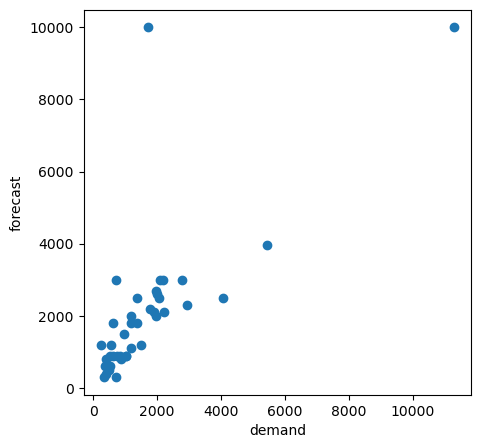

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter([wines_historical[w]['demand'] for w in wines_historical],[wines_historical[w]['forecast'] for w in wines_historical])
plt.xlabel('demand')
plt.ylabel('forecast')
plt.show()

### 4. Determine mean and standard deviation of demand/forecast ratios

In [ ]:
#---using the historical data, a for loop is used to populate the list of 
#   demand/forecast ratios into a list called "ratios"
#   Use this list to calculate the mean and the standard deviation of these ratios

ratios = []
for w in wines_historical:
    ratios.append(wines_historical[w]['demand']/wines_historical[w]['forecast'])

mean_ratio = sum(ratios)/len(ratios)
std_ratio = np.std(ratios)

print('mean   ',mean_ratio)
print('std dev',std_ratio)



mean    0.865281283257805
std dev 0.3927890983695895


In [ ]:
ratios

[1.128,
 0.21,
 0.6,
 1.08,
 0.723,
 1.1488888888888888,
 0.64,
 1.035,
 0.34,
 1.3727272727272728,
 0.88,
 1.1266666666666667,
 1.25,
 0.828,
 0.928,
 0.987,
 1.6228,
 0.7661538461538462,
 0.242,
 0.5025,
 0.552,
 0.68,
 0.65,
 0.64,
 0.7,
 1.2756521739130435,
 2.3433333333333333,
 0.96,
 0.7288888888888889,
 0.7533333333333333,
 1.08,
 0.4725,
 0.8233333333333334,
 0.9095238095238095,
 0.588,
 0.8127272727272727,
 0.9266666666666666,
 1.0514285714285714,
 1.0827272727272728,
 0.1704]

In [ ]:
#This is for EACH wine

mean_demand = {}
std_demand = {}
for w in wines_prediction: 
    mean_demand[w] = wines_prediction[w]['forecast']*mean_ratio
    std_demand[w] = wines_prediction[w]['forecast']*std_ratio
for w in wines_prediction : 
    print("For the wine n°", w, " the average demand is : ", mean_demand[w], "and the standard deviation is : ", std_demand [w])



For the wine n° 1  the average demand is :  10383.37539909366 and the standard deviation is :  4713.469180435074
For the wine n° 2  the average demand is :  648.9609624433538 and the standard deviation is :  294.59182377719213
For the wine n° 3  the average demand is :  865.281283257805 and the standard deviation is :  392.78909836958945
For the wine n° 4  the average demand is :  1124.8656682351464 and the standard deviation is :  510.6258278804663
For the wine n° 5  the average demand is :  2768.900106424976 and the standard deviation is :  1256.9251147826863
For the wine n° 6  the average demand is :  3461.12513303122 and the standard deviation is :  1571.1563934783578
For the wine n° 7  the average demand is :  1124.8656682351464 and the standard deviation is :  510.6258278804663
For the wine n° 8  the average demand is :  1297.9219248867075 and the standard deviation is :  589.1836475543843
For the wine n° 9  the average demand is :  5191.68769954683 and the standard deviation is 

In [ ]:
# This is for ALL wines (but not really useful)

mean_demand = {}
std_demand = {}
for w in wines_prediction:
    mean_demand[w] = wines_prediction[w]['forecast']*mean_ratio
    std_demand[w] = wines_prediction[w]['forecast']*std_ratio
    
total=[]
totalstd=[]
for w in wines_prediction : 
    #print("For the wine n°", w, "the average demand is :", mean_demand[w], "and the standard deviation is :", std_demand[w])
    total.append(mean_demand[w])
    totalstd.append(std_demand[w])
print("The total average demand is", np.mean(total))
print("The average std for all wines is", np.mean(totalstd))


The total average demand is 2683.814113571292
The average std for all wines is 1218.3008534430103


### 5. Calculate Cu, Co and the critical ratio for each wine of the prediction dataset
<ul>
<li>$C_o$ represents the cost of overage </li>
<li>$C_u$ represents the cost of underage</li>
</ul>
The critical ratio is: $\frac{C_u}{C_u+C_o}$

In [ ]:
#---Computing Cu and Co

Cu = {}
Co = {}
#---Case parameters
shipping = {'Rouge':1.25, 'Not_rouge':1.25}
ware_time = {'Rouge':15, 'Not_rouge':8}
discount = {'Rouge':0.3, 'Not_rouge':0.4}

for w in wines_prediction:
    Cu[w] = wines_prediction[w]['price']*0.5 - 1.25
    if wines_prediction[w]['color'] == 'Rouge':
        Co[w] = wines_prediction[w]['price']*(0.5 - (1-discount['Rouge']) + 0.15*ware_time['Rouge']/24)
        Co[w] += 0.1*ware_time['Rouge'] + shipping['Rouge']        
        
    else:
        Co[w] = wines_prediction[w]['price']*(0.5 - (1-discount['Not_rouge']) + 0.15*ware_time['Not_rouge']/24)
        Co[w] += 0.1*ware_time['Not_rouge'] + shipping['Not_rouge']        
      
    print('%d\t%.3f\t%.3f' % (w,Cu[w],Co[w])) 
    


1	2.150	2.028
2	3.700	1.555
3	2.950	1.858
4	8.200	0.742
5	4.825	1.442
6	1.500	1.775
7	2.350	1.985
8	1.325	1.792
9	1.075	2.256
10	1.725	1.752
11	1.000	2.272
12	0.375	2.405
13	0.400	1.885
14	0.400	1.885
15	0.545	1.870
16	1.550	1.770
17	4.750	1.450
18	1.675	2.128
19	9.700	0.423
20	2.350	1.690
21	5.200	1.379
22	1.425	2.182
23	3.200	1.804
24	5.700	1.273
25	1.550	2.155
26	3.485	1.577
27	1.600	2.144
28	1.650	2.134
29	1.355	2.196
30	3.250	1.794


### Plot the relationship between wine price and Cu

In [ ]:
prices = [wines_prediction[w]['price'] for w in wines_prediction]
cu_vals = [Cu[w] for w in wines_prediction]


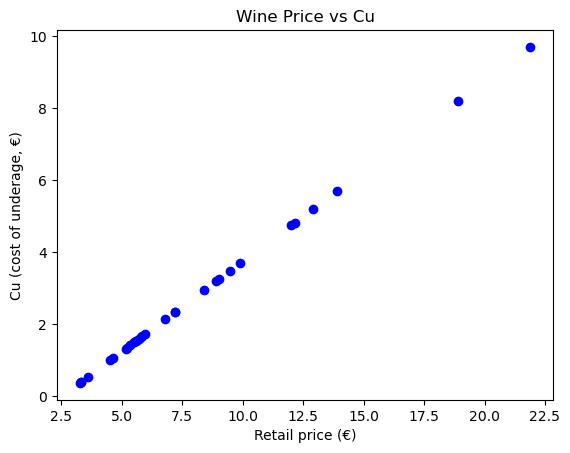

In [ ]:
plt.scatter(prices, cu_vals, color='blue')
plt.xlabel('Retail price (€)')
plt.ylabel('Cu (cost of underage, €)')
plt.title('Wine Price vs Cu')
plt.show()

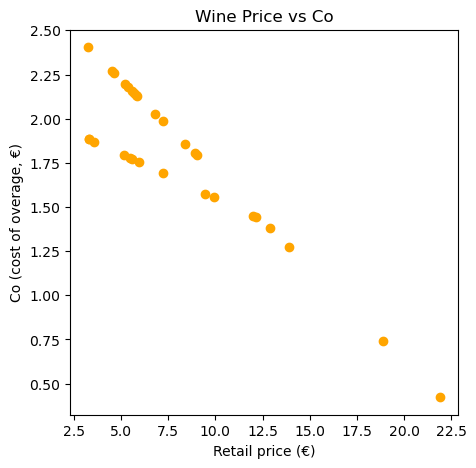

In [ ]:
co_vals = [Co[w] for w in wines_prediction]
plt.figure(figsize=(5,5))
plt.scatter(prices, co_vals, color='orange')
plt.xlabel('Retail price (€)')
plt.ylabel('Co (cost of overage, €)')
plt.title('Wine Price vs Co')
plt.show()

### 6. Function toolbox

In [ ]:
#---function that calculates the profit-maximizing quantity of wine w to be ordered
def get_Quantity_for_Profit(w):
    cr = Cu[w]/(Cu[w]+Co[w])
    q = stats.norm.ppf(cr)
    Q = mean_demand[w] + std_demand[w]*q    
    return Q

#---function that calculates the maximal expected profit of wine w 
def get_ExpectedProfit(w):
    cr = Cu[w]/(Cu[w]+Co[w])
    q = stats.norm.ppf(cr)
    Q = mean_demand[w] + std_demand[w]*q    
    L = stats.norm.pdf(q) - q*(1 - stats.norm.cdf(q))
    ELS = std_demand[w]*L
    ES = mean_demand[w] - ELS    
    ELI = Q - ES
    expected_profit = Cu[w]*ES - Co[w]*ELI    
    return expected_profit

#---function that calculates the instock (in %) of wine w given a desired quantity Q
def get_InStock_given_Quantity(w,Q):
    instock = 100.0*(stats.norm.cdf((Q-mean_demand[w])/std_demand[w]))
    return instock

#---function that calculates the quantity of wine w to be ordered given a desired in-stock alpha
def get_Quantity_for_InStock(w,alpha):
    Q = mean_demand[w] + std_demand[w]*(stats.norm.ppf(alpha))
    return Q

#---function that calculates the profit for a given quantity Q
def get_ExpectedProfit_given_Quantity(w,Q):
    q = (Q - mean_demand[w])/std_demand[w]
    L = stats.norm.pdf(q) - q*(1 - stats.norm.cdf(q))
    ELS = std_demand[w]*L
    ES = mean_demand[w] - ELS
    ELI = Q - ES
    expected_profit = Cu[w]*ES - Co[w]*ELI
    return expected_profit


### 7. Use the functions from the toolbox to answer questions

In [ ]:
p60 = 60.0
Cu60 = p60 * 0.5 - 1.25
Co60 = p60 * (0.5 - (1 - 0.3) + 0.15 * (15 / 24)) + (0.1 * 15) + 1.25
cr60 = Cu60 / (Cu60 + Co60)

print("Price = 60")
print("Cu    = ",Cu60)
print("Co    =", Co60) 
print("Critical ratio = ",cr60)
print()

Price = 60
Cu    =  28.75
Co    = -3.6249999999999973
Critical ratio =  1.144278606965174



In [ ]:
p60 = 60.0
Cu60 = p60 * 0.5 - 1.25
Co60 = p60 * (0.5 - (1 - 0.4) + 0.15 * 8 / 24) + 0.1 * 8 + 1.25
cr60 = Cu60 / (Cu60 + Co60)
print("Price = 60")
print("Cu    = ",Cu60)
print("Co    =", Co60) 
print("Critical ratio = ",cr60)
print()

Price = 60
Cu    =  28.75
Co    = -0.9499999999999993
Critical ratio =  1.0341726618705036



In [ ]:
#vin fictif à €60
wines_prediction[99] = {'color': 'Blanc', 'price': 60.0, 'forecast': 1000}

# Cu et Co pour ce vin
Cu[99] = 60.0 * 0.5 - 1.25
Co[99] = 60.0*(0.5 - (1-0.4) + 0.15*8/24) + 0.1*8 + 1.25

# Calculer mean et std demand
mean_demand[99] = mean_ratio * 1000
std_demand[99]  = std_ratio  * 1000

print(get_Quantity_for_Profit(99)) 
print(get_InStock_given_Quantity(99, get_Quantity_for_Profit(99)))


nan
nan


In [ ]:
#question 8 exemple de pessac leognan
w = 4  # PESSAC LEOGNAN Ch. Haut Nouchet

Q = get_Quantity_for_Profit(w)
print("Q* =", Q)  

IS = get_InStock_given_Quantity(w, Q)
print("InStock =", IS) 

EP = get_ExpectedProfit(w)
print("Expected Profit =", EP)  


Q90 = get_Quantity_for_InStock(w, 0.90)
print("Q at 90% SL =", Q90)  

EP90 = get_ExpectedProfit_given_Quantity(w, Q90)
print("Expected Profit at Q90 =", EP90)

Q* = 1832.2823974660234
InStock = 91.70336199063395
Expected Profit = 8526.198683106035
Q at 90% SL = 1779.2589973628656
Expected Profit at Q90 = 8522.253746806602


In [ ]:
#Question 5
#Functions to find the right quantity to order
def get_Quantity_for_Profit(w):
    cr = Cu[w]/(Cu[w]+Co[w])
    q = stats.norm.ppf(cr)
    Q = mean_demand[w] + std_demand[w]*q    
    return Q

def get_Quantity_for_InStock(w,alpha):
    Q = mean_demand[w] + std_demand[w]*(stats.norm.ppf(alpha))
    return Q

    
#Find the right wine to work on
for w in wines_prediction:
    if wines_prediction[w]['Appellation']=="CÃ”TES DE BOURG":
        if wines_prediction[w]['Designation']=='Ch. Florimond':
            wine_index2= None
            wine_index2=w
print(wine_index2)

        
# Give Cu et Co
print('Cu=',Cu[wine_index2],'  ','Co=',Co[wine_index2])
#use the function to maximize profit with this wine
print(get_Quantity_for_Profit(wine_index2))

#use the function to calculate the quantity to order to be sure at 95% to satisfy the demand
print (get_Quantity_for_InStock(wine_index2,0.95))

In [ ]:
#Find the syntax that the notebook uses for each wine name
for w in wines_prediction:
    if 'DE BOURG' in wines_prediction[w]['Appellation'] or 'Florimond' in wines_prediction[w]['Appellation']:
        print(f"{w}: {repr(wines_prediction[w]['Appellation'])}")
        print(f"    {repr(wines_prediction[w]['Designation'])}")